# Exploratory Spatial Data Analysis (ESDA)

## Notebook 3

### Urban Heat Island Analysis of Nagpur, India Using Earth Observation and Explainable Machine Learning

**Author:** Shreya Jariwala

---

## 1. Purpose

This notebook investigates the relationships between the environmental variables derived in Notebook 2.

The objective is to understand how vegetation, built-up surfaces, and surface moisture influence land surface temperature before developing predictive machine learning models.

The notebook also prepares the final machine learning dataset used in subsequent analysis.

## 2. Why Exploratory Spatial Data Analysis?

Before training a machine learning model, it is essential to understand the structure of the data.

Exploratory Spatial Data Analysis (ESDA) combines traditional exploratory data analysis with spatial reasoning to identify patterns, relationships, and anomalies within geographic datasets.

Understanding these relationships improves model interpretation and provides evidence for the environmental processes driving the Urban Heat Island effect.

In [1]:

# Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import rioxarray

from pathlib import Path

In [3]:
# Project Configuration

DATA_DIR = Path("data/processed")

print("Exploratory Spatial Data Analysis")

print(f"Input Directory : {DATA_DIR.resolve()}")

Exploratory Spatial Data Analysis
Input Directory : /Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/data/processed


## 3. Load Processed Feature Layers

The engineered environmental variables generated in Notebook 2 are loaded directly from GeoTIFF files.

Using georeferenced raster files ensures that all variables remain spatially aligned and preserves the coordinate reference system required for spatial analysis.

In [4]:
# Load Processed Features


lst = rioxarray.open_rasterio(DATA_DIR / "lst.tif").squeeze()

ndvi = rioxarray.open_rasterio(DATA_DIR / "ndvi.tif").squeeze()

ndbi = rioxarray.open_rasterio(DATA_DIR / "ndbi.tif").squeeze()

ndwi = rioxarray.open_rasterio(DATA_DIR / "ndwi.tif").squeeze()

print("Feature layers loaded successfully.")

Feature layers loaded successfully.


In [5]:

# Raster Validation

print("Raster Validation")

for name, raster in zip(
    ["LST", "NDVI", "NDBI", "NDWI"],
    [lst, ndvi, ndbi, ndwi]
):
    print(f"{name}")
    print(f"Shape : {raster.shape}")
    print(f"CRS   : {raster.rio.crs}")
    print(f"Min   : {float(raster.min()):.3f}")
    print(f"Max   : {float(raster.max()):.3f}")
    print("-" * 40)

Raster Validation
LST
Shape : (990, 970)
CRS   : EPSG:32644
Min   : 27.921
Max   : 50.671
----------------------------------------
NDVI
Shape : (990, 970)
CRS   : EPSG:32644
Min   : -0.348
Max   : 0.842
----------------------------------------
NDBI
Shape : (990, 970)
CRS   : EPSG:32644
Min   : -0.650
Max   : 0.364
----------------------------------------
NDWI
Shape : (990, 970)
CRS   : EPSG:32644
Min   : -0.732
Max   : 0.401
----------------------------------------


## 4. Create the Machine Learning Dataset

Machine learning algorithms require tabular data rather than raster datasets.

Each raster is therefore converted into a one-dimensional array, where every pixel becomes one observation.

The resulting dataset contains one row per valid pixel and one column for each environmental variable.

This transformation creates the analysis-ready dataset used throughout the remainder of the project.

In [6]:

# Create Machine Learning Dataset

print("Creating Machine Learning Dataset...")

df = pd.DataFrame({

    "LST": lst.values.ravel(),

    "NDVI": ndvi.values.ravel(),

    "NDBI": ndbi.values.ravel(),

    "NDWI": ndwi.values.ravel()

})

print("Dataset successfully created.")

print(f"\nRows    : {len(df):,}")

print(f"Columns : {len(df.columns)}")

print("\nColumns:")

print(df.columns.tolist())

Creating Machine Learning Dataset...
Dataset successfully created.

Rows    : 960,300
Columns : 4

Columns:
['LST', 'NDVI', 'NDBI', 'NDWI']


## 5. Preview the Dataset

Before performing statistical analysis, the first few rows of the machine learning dataset are inspected to verify that all variables have been correctly assembled into tabular form.

In [ ]:
# Preview Dataset

print("First Five Rows")

display(df.head())

First Five Rows


,LST,NDVI,NDBI,NDWI
0,37.857312,0.429916,-0.088507,-0.480984
1,36.561882,0.402029,-0.056802,-0.466794
2,35.830426,0.374392,-0.045050,-0.448279
3,35.389502,0.349585,-0.074282,-0.424855
4,35.300633,0.509524,-0.215619,-0.522606


## 6. Data Cleaning

Machine learning algorithms require complete numerical datasets.

Before statistical analysis, missing values and invalid observations are removed to ensure that all remaining samples are suitable for quantitative analysis.

This preprocessing step improves model reliability and prevents computational errors during later stages of the workflow.

In [ ]:

# Clean the Machine Learning Dataset

print("Cleaning Dataset...")

# Original size
original_rows = len(df)

# Replace infinities with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Remove missing values
df = df.dropna()

# Reset index
df = df.reset_index(drop=True)

print(f"Original Rows : {original_rows:,}")
print(f"Remaining Rows: {len(df):,}")
print(f"Rows Removed  : {original_rows - len(df):,}")

Cleaning Dataset...
Original Rows : 960,300
Remaining Rows: 960,300
Rows Removed  : 0


In [10]:

# Verify Missing Values

print("Missing Values")

print(df.isnull().sum())

Missing Values
LST     0
NDVI    0
NDBI    0
NDWI    0
dtype: int64


## 7. Descriptive Statistics

Summary statistics provide an overview of the distribution of each environmental variable across the study area.

These metrics help identify the overall range, central tendency, and variability of the dataset before further analysis.

In [11]:
# Descriptive Statistics

print("Descriptive Statistics")

stats = df.describe().round(3)

display(stats)

Descriptive Statistics


,LST,NDVI,NDBI,NDWI
count,960300.000,960300.000,960300.000,960300.000
mean,37.616,0.383,-0.056,-0.417
std,2.130,0.115,0.086,0.097
min,27.921,-0.348,-0.650,-0.732
25%,36.411,0.308,-0.104,-0.481
50%,37.625,0.383,-0.044,-0.431
75%,38.886,0.455,0.003,-0.365
max,50.671,0.842,0.364,0.401


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) provides an overview of the statistical characteristics of the engineered environmental variables.

Visualizing the distributions helps identify skewness, outliers, multimodal behaviour, and potential issues that could influence machine learning performance.

Understanding these distributions also provides insight into the environmental characteristics of the study area.

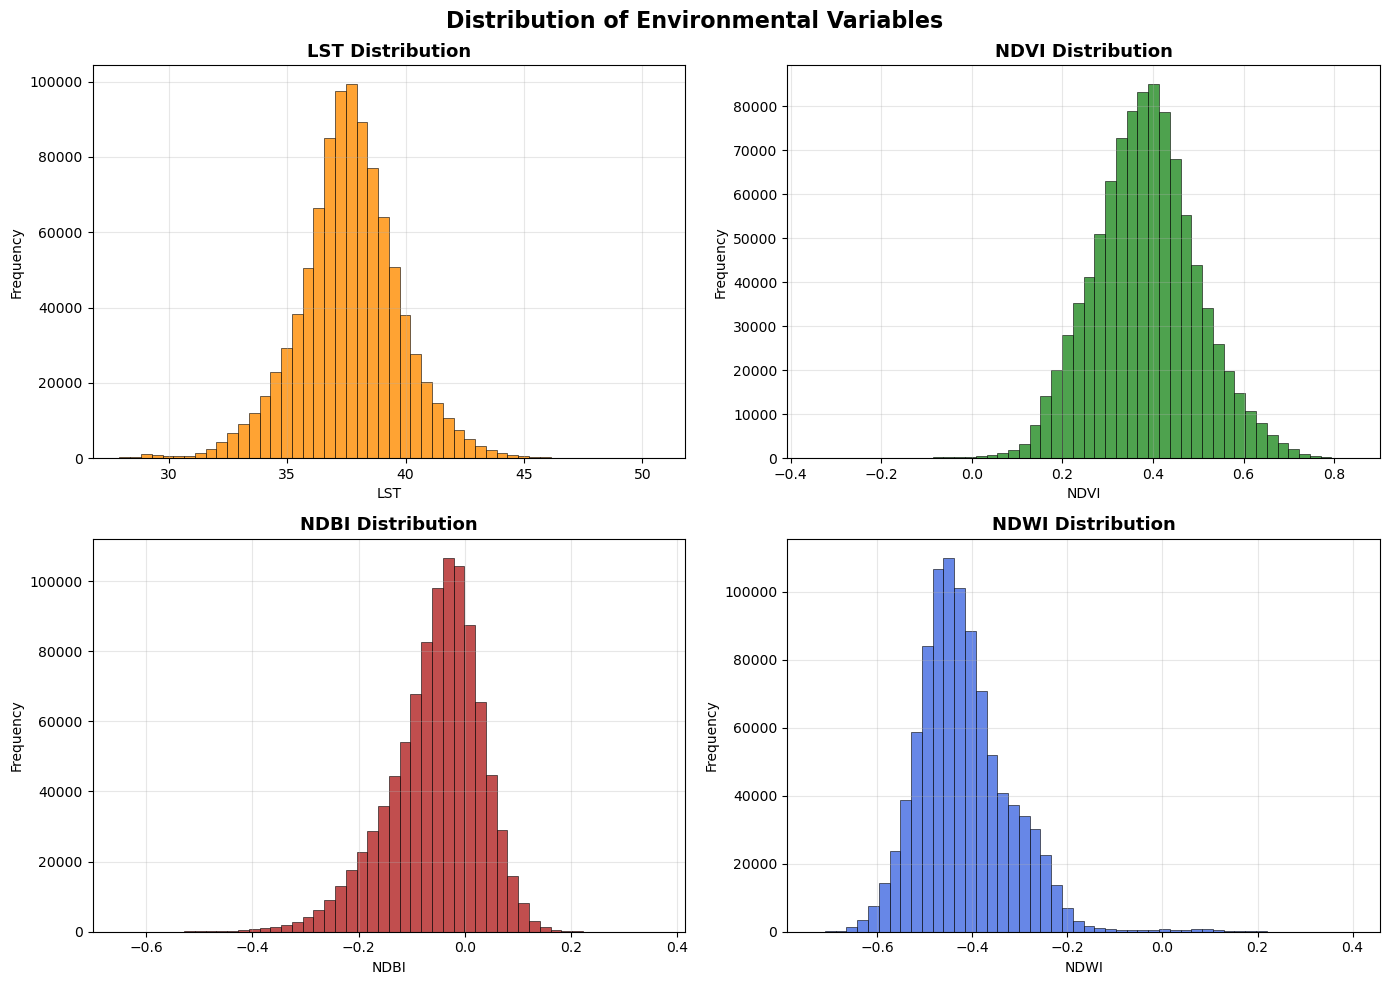

In [ ]:

# Distribution of Environmental Variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = [
    ("LST", "darkorange"),
    ("NDVI", "forestgreen"),
    ("NDBI", "firebrick"),
    ("NDWI", "royalblue")
]

for ax, (column, color) in zip(axes.flatten(), variables):

    ax.hist(
        df[column],
        bins=50,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8
    )

    ax.set_title(
        f"{column} Distribution",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

    ax.grid(alpha=0.3)

plt.suptitle(
    "Distribution of Environmental Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 9. Boxplot Analysis

Boxplots summarize the statistical distribution of each environmental variable, highlighting the median, interquartile range, and potential outliers.

These plots provide an efficient way to compare variability across the engineered features.

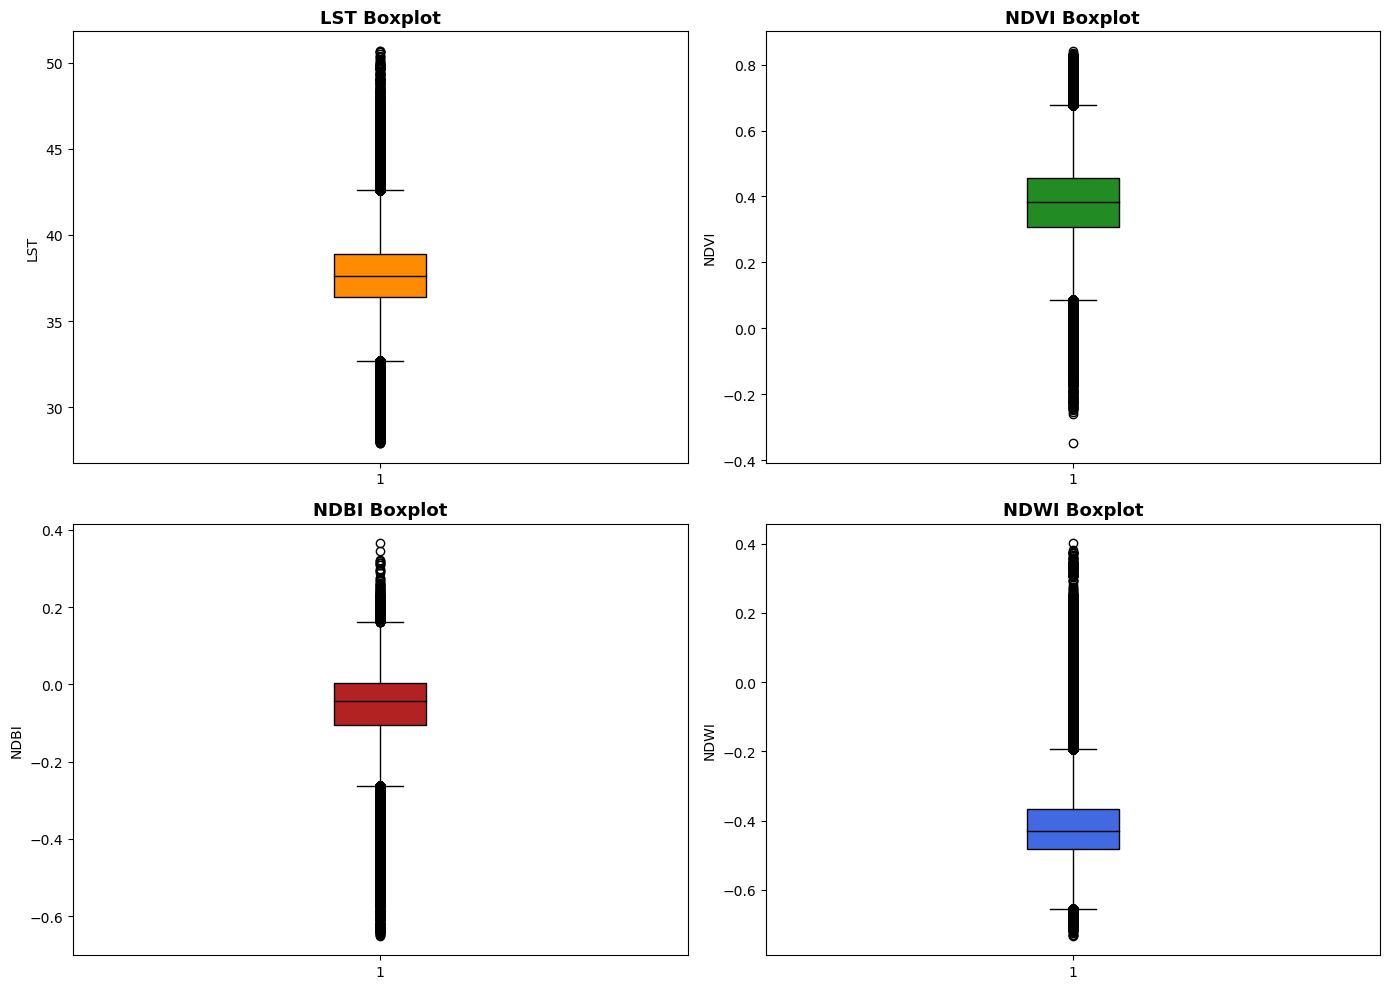

In [ ]:

# Boxplots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (column, color) in zip(axes.flatten(), variables):

    ax.boxplot(
        df[column],
        patch_artist=True,

        boxprops=dict(facecolor=color),

        medianprops=dict(color="black")
    )

    ax.set_title(
        f"{column} Boxplot",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel(column)

plt.tight_layout()

plt.show()

## 10. Correlation Analysis

Correlation analysis quantifies the strength and direction of the relationships between the engineered environmental variables.

Understanding these relationships provides statistical evidence for the environmental processes influencing urban heat and helps identify the most informative predictors for subsequent machine learning models.

Pearson's correlation coefficient is used to measure linear relationships between variables.

In [ ]:

# Compute Pearson Correlation Matrix

print("Computing Correlation Matrix...")

correlation_matrix = df.corr(method="pearson")

print("Correlation matrix successfully computed.")

display(correlation_matrix.round(3))

Computing Correlation Matrix...
Correlation matrix successfully computed.


,LST,NDVI,NDBI,NDWI
LST,1.000,-0.422,0.623,0.260
NDVI,-0.422,1.000,-0.693,-0.943
NDBI,0.623,-0.693,1.000,0.507
NDWI,0.260,-0.943,0.507,1.000


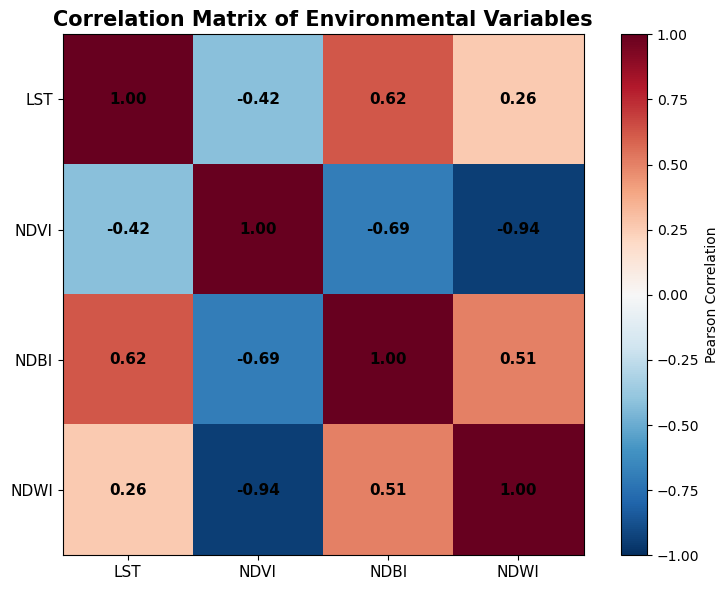

In [ ]:

# Correlation Heatmap

fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(
    correlation_matrix,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# Axis labels
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, fontsize=11)
ax.set_yticklabels(correlation_matrix.columns, fontsize=11)

# Add correlation values
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11,
            fontweight="bold"
        )

cbar = plt.colorbar(heatmap)

cbar.set_label("Pearson Correlation")

plt.title(
    "Correlation Matrix of Environmental Variables",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 11. Relationship Between Environmental Variables and Land Surface Temperature

To identify the strongest environmental controls on urban heat, the correlation of each predictor variable with land surface temperature is ranked from strongest to weakest.

In [ ]:

# Rank Correlations with LST

lst_correlations = (
    correlation_matrix["LST"]
    .drop("LST")
    .sort_values(key=abs, ascending=False)
)

print("Correlation with Land Surface Temperature")

display(lst_correlations.round(3))

Correlation with Land Surface Temperature


NDBI    0.623
NDVI   -0.422
NDWI    0.260
Name: LST, dtype: float64

## 12. Interpretation

The correlation analysis reveals statistically meaningful relationships between the engineered environmental variables.

Built-up intensity (NDBI) exhibits the strongest positive correlation with land surface temperature (r = 0.623), indicating that impervious urban surfaces are associated with increased surface heating. Vegetation density (NDVI) shows a moderate negative correlation with land surface temperature (r = -0.422), supporting the well-established cooling effects of vegetation through shading and evapotranspiration.

Surface moisture (NDWI) demonstrates a weaker positive correlation with land surface temperature (r = 0.260). This relationship likely reflects the influence of annual compositing, surrounding land cover, and the fact that NDWI captures both open water and moisture conditions rather than water bodies alone.

The strong negative correlation between NDVI and NDWI (r = -0.943) suggests that these variables share substantial information within the study area. Although this indicates multicollinearity, tree-based machine learning algorithms such as Random Forest and XGBoost are generally robust to correlated predictors.

Overall, the correlation analysis supports the hypothesis that urbanization contributes to higher land surface temperatures, while vegetation mitigates the Urban Heat Island effect.

## 13. Spatial Relationship Analysis

Scatter plots provide a visual representation of the relationships between land surface temperature and the engineered environmental variables.

Unlike the correlation matrix, which summarizes linear relationships numerically, scatter plots reveal the overall structure of the data, including trends, variability, and potential nonlinear behaviour.

A random subset of pixels is used to improve visualization while preserving the statistical characteristics of the dataset.

In [ ]:

# Sample Dataset for Visualization

print("Creating Visualization Sample...")

sample_size = 50000

plot_df = df.sample(
    n=sample_size,
    random_state=42
)

print(f"Sample Size: {len(plot_df):,} pixels")

Creating Visualization Sample...
Sample Size: 50,000 pixels


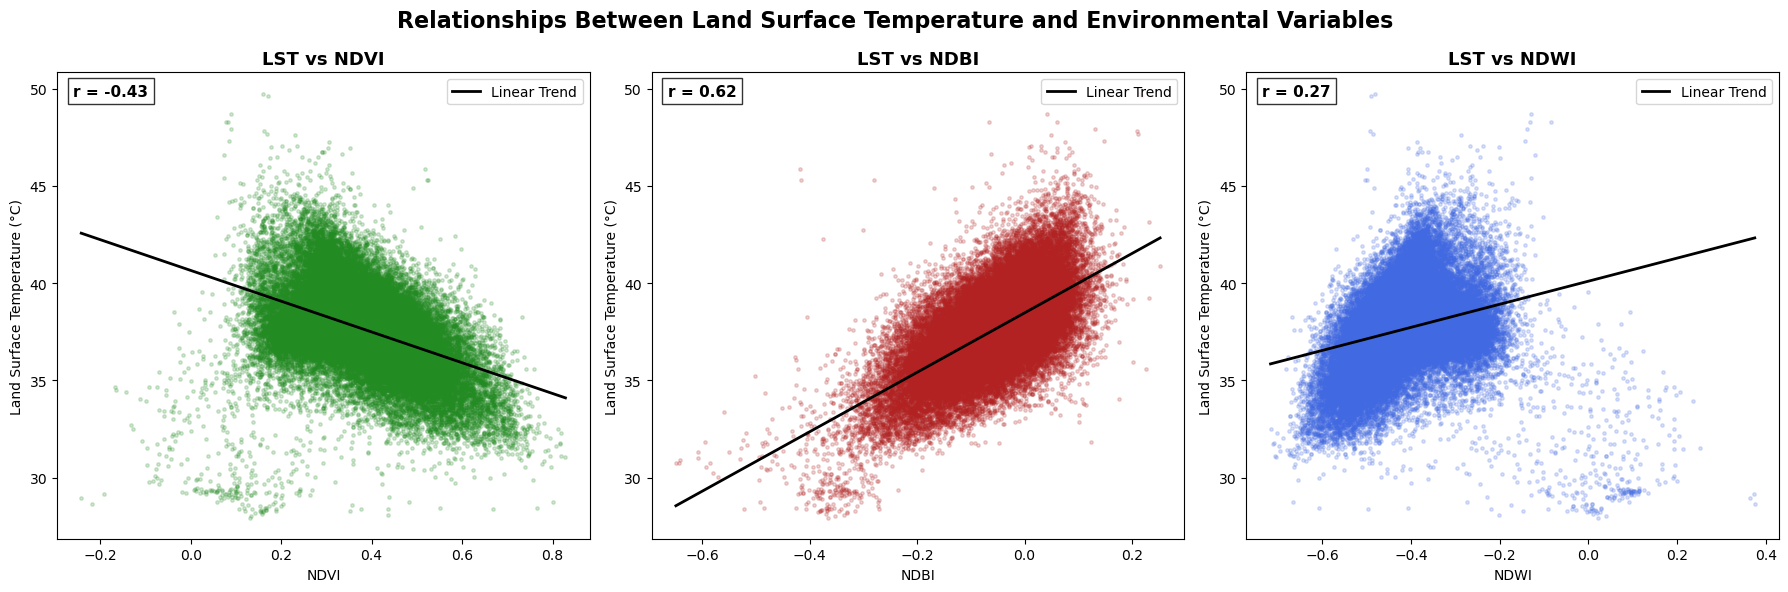

In [ ]:

# Scatter Plots with Regression Lines

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

relationships = [
    ("NDVI", "forestgreen"),
    ("NDBI", "firebrick"),
    ("NDWI", "royalblue")
]

for ax, (feature, color) in zip(axes, relationships):

    # Scatter points
    ax.scatter(
        plot_df[feature],
        plot_df["LST"],
        s=6,
        alpha=0.20,
        color=color
    )

    # Regression line
    coefficients = np.polyfit(
        plot_df[feature],
        plot_df["LST"],
        1
    )

    regression = np.poly1d(coefficients)

    x = np.linspace(
        plot_df[feature].min(),
        plot_df[feature].max(),
        200
    )

    ax.plot(
        x,
        regression(x),
        color="black",
        linewidth=2,
        label="Linear Trend"
    )

    # Correlation coefficient
    r = plot_df["LST"].corr(plot_df[feature])

    ax.text(
        0.03,
        0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    ax.set_title(
        f"LST vs {feature}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Land Surface Temperature (°C)")
    ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=10
)

plt.suptitle(
    "Relationships Between Land Surface Temperature and Environmental Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 14. Export the Machine Learning Dataset

The cleaned environmental dataset is exported as a CSV file.

Each row represents one valid pixel within the study area, while each column represents an engineered environmental variable.

This tabular dataset serves as the primary input for the machine learning workflows developed in Notebook 4.

In [ ]:

# Final Dataset Validation

print("Final Dataset Validation")

print(f"Number of observations : {len(df):,}")
print(f"Number of variables    : {len(df.columns)}")

print("\nVariables:")

for column in df.columns:
    print(f"• {column}")

print("\nMissing Values")

display(df.isnull().sum())

print("\nData Types")

display(df.dtypes)

Final Dataset Validation
Number of observations : 960,300
Number of variables    : 4

Variables:
• LST
• NDVI
• NDBI
• NDWI

Missing Values


LST     0
NDVI    0
NDBI    0
NDWI    0
dtype: int64


Data Types


LST     float64
NDVI    float64
NDBI    float64
NDWI    float64
dtype: object

In [ ]:

# Create Output Directory

from pathlib import Path

ML_DIR = Path("data/ml")

ML_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory created.")

print(ML_DIR.resolve())

Output directory created.
/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/data/ml


In [ ]:

# Export Machine Learning Dataset

output_file = ML_DIR / "urban_heat_dataset.csv"

df.to_csv(
    output_file,
    index=False
)

print("Export Complete")

print(f"Saved to:\n{output_file.resolve()}")

Export Complete
Saved to:
/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/data/ml/urban_heat_dataset.csv


In [ ]:

# Verify Export

verification_df = pd.read_csv(output_file)

print("Verification successful.\n")

print(f"Rows    : {len(verification_df):,}")

print(f"Columns : {len(verification_df.columns)}")

display(verification_df.head())

Verification successful.

Rows    : 960,300
Columns : 4


,LST,NDVI,NDBI,NDWI
0,37.857312,0.429916,-0.088507,-0.480984
1,36.561882,0.402029,-0.056802,-0.466794
2,35.830426,0.374392,-0.045050,-0.448279
3,35.389502,0.349585,-0.074282,-0.424855
4,35.300633,0.509524,-0.215619,-0.522606


## 15. Key Findings

The exploratory spatial data analysis revealed several important relationships between environmental variables and urban thermal patterns.

### Main Findings

- Built-up areas (NDBI) showed the strongest positive correlation with land surface temperature.
- Vegetation (NDVI) exhibited a moderate negative correlation with temperature, indicating the cooling influence of green spaces.
- Moisture conditions (NDWI) demonstrated weaker spatial associations with temperature compared to vegetation and built-up surfaces.
- The predictor variables exhibited meaningful spatial variability suitable for machine learning.

These findings provide strong evidence that the engineered environmental variables are appropriate predictors for land surface temperature modelling in the subsequent machine learning workflow.

## 16. Notebook Summary

## Overview

This notebook transformed the geospatial feature layers generated in Notebook 2 into an analysis-ready machine learning dataset.

Exploratory Spatial Data Analysis (ESDA) was used to investigate the statistical characteristics and relationships among the engineered environmental variables before predictive modelling.

---

## Key Accomplishments

### Data Preparation

- Loaded georeferenced environmental feature layers
- Verified spatial alignment and coordinate reference systems
- Converted raster data into a pixel-based machine learning dataset
- Removed invalid observations and missing values

### Exploratory Data Analysis

- Examined the statistical distributions of each variable
- Identified the range and variability of land surface temperature, vegetation, built-up intensity, and surface moisture
- Investigated pairwise relationships between environmental variables

### Correlation Analysis

Correlation analysis demonstrated that:

- Built-up intensity (NDBI) exhibited the strongest positive relationship with land surface temperature.
- Vegetation (NDVI) showed a moderate negative relationship with temperature.
- Surface moisture (NDWI) displayed a weaker positive linear relationship.
- The engineered variables provide meaningful environmental information for predictive modelling.

### Dataset Export

The final cleaned machine learning dataset was exported as a CSV file for use in Notebook 4.

---

## Next Steps

Notebook 4 develops predictive machine learning models using Random Forest and XGBoost to estimate land surface temperature from the engineered environmental variables.

Model performance, feature importance, and explainable AI techniques (SHAP values) will be used to understand the environmental drivers of the Urban Heat Island effect.


## 17. Next Notebook

The next notebook develops and evaluates machine learning models for predicting urban land surface temperature.

The workflow includes:

- Data splitting
- Random Forest modelling
- XGBoost modelling
- Model evaluation
- Feature importance analysis
- Explainable AI using SHAP

➡️ **Proceed to Notebook 4: Machine Learning and Explainable AI**